In [66]:
import sys
import os

# 1. Le decimos a Jupyter que suba un nivel de carpeta para mirar todo el proyecto DSP_GIT
ruta_raiz = os.path.abspath('..')

# Si la ruta no está registrada, la agregamos
if ruta_raiz not in sys.path:
    sys.path.append(ruta_raiz)

# 2. Activamos la recarga automática (Vital para procesamiento de señales)
%load_ext autoreload
%autoreload 2

# 3. Importamos tus scripts desde la carpeta "funciones"
import funciones.filtros as flt
import funciones.ploters as plts
import funciones.respuesta_impulso as ri
import funciones.file_manager as fm
import funciones.conversores as conv

#4. Importamos Librerias

import numpy as np

import soundfile as sf
import matplotlib.pyplot as plt
from scipy import signal as sig
import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Ejercicio 1 - Repaso 
Un renombrado pianista se encuentra en el medio de la grabación de su nuevo disco y fuimos lo suficientemente afortunados como para tener acceso a una sesión hecha en la Usina del Arte. Como es usual, se realizó una toma directa del instrumento, es decir, con un micrófono muy cerca de la fuente. Además, para aprovechar el recinto el/la ingenierx de sonido a cargo decidió realizar varias tomas en distintos puntos del teatro, en una jornada que se extendió hasta altas horas de la madrugada.

Semanas después, en la etapa de mezcla del disco, se decidió utilizar la toma directa y una de las tomas hechas desde lejos, para poder representar correctamente tanto al instrumento como al recinto. Al tratar de trabajar con dichas pistas el equipo se dio cuenta de que había un problema casi insalvable. La distancia entre las posiciones de micrófono sumada a la variación de la velocidad del sonido generada por el malhumor y el tedio de la grabación provocaron un retraso temporal significativo en el arribo de la señal al micrófono alejado de la fuente. Como consecuencia, las dos señales en cuestión presentan un desfasaje temporal que hace imposible procesarlas en conjunto sin ningún pre-procesamiento.

Su tarea es justamente aplicar el pre-procesamiento necesario para que las dos pistas queden alineadas temporalmente, permitiendo que lxs que saben sigan con su trabajo. Para lograr esto deben aplicar los conocimientos que hayan adquirido/recordado durante las clases de repaso, fundamentalmente las ideas relacionadas a la correlación cruzada y/o a la convolución lineal.

A continuación les presentamos una lista no exhaustiva de librerías de Python que les pueden servir para su tarea:

Librosa y Soundfile, para leer y escribir archivos de audio.

Matplotlib, para gráficos.

Numpy y el módulo Signal de SciPy, para procesar las señales de audio. Puntualmente las funciones correlate/convolve de Numpy y correlate/fftconvolve de Scipy pueden serles de ayuda.

El objetivo principal es lograr alinear las señales, pero como objetivos secundarios pueden plantearse:

Comparar los resultados de numpy.correlate y scipy.signal.correlate, ¿son equivalentes? ¿hay diferencias en los tiempos de ejecución? ¿por qué?.

Grafiquen las señales, recordando siempre el formato discutido en la clase de Programación Básica (títulos en los ejes, unidades de las magnitudes, leyendas, etc.).

In [67]:
# 1. Lectura de archivos con Soundfile
# sf.read devuelve (data, samplerate)
s_cerca,sr = sf.read('piano_cerca.wav')
s_lejos,_ = sf.read('piano_lejos.wav')
print(sr)

48000


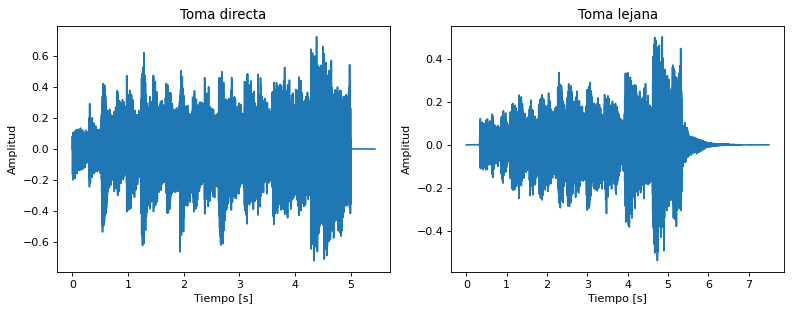

In [68]:
t1 = np.linspace(0, len(s_cerca)/sr, num = len(s_cerca))
t2 = np.linspace(0,len(s_lejos)/sr, num = len(s_lejos))

plt.figure(figsize=(10, 4), dpi=80)

#Plot toma directa 
plt.subplot(1,2,1)
plt.plot(t1,s_cerca)
plt.ylabel('Amplitud')
plt.xlabel('Tiempo [s]')
plt.title('Toma directa')

#Plot toma lejana
plt.subplot(1,2,2)
plt.plot(t2,s_lejos)
plt.ylabel('Amplitud')
plt.xlabel('Tiempo [s]')
plt.title('Toma lejana')
plt.tight_layout()
plt.show()

Podemos ver que la toma lejana tiene una amplitud mucho menor que la toma directa, lo que es consistente con la idea de que el micrófono está más lejos de la fuente sonora. Además, la forma de onda de la toma lejana puede mostrar más reverberación o ruido ambiental debido a la distancia.    

Analizamos la correlacion entre ambas señales


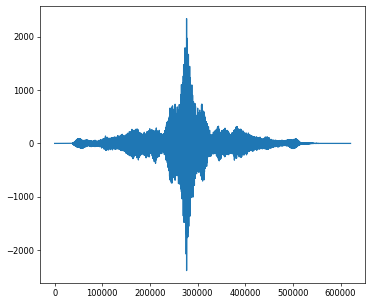

In [69]:
corr_s = sig.correlate(s_lejos,s_cerca)
plt.figure(figsize=(7, 6), dpi=60)
plt.plot(corr_s,)

### Analisis Eje X
Cuando haces plt.plot(corr_s), Matplotlib no sabe nada de física ni de tiempo; simplemente grafica el primer valor de la lista en la posición 0, el segundo en la 1, y así hasta llegar a ~600,000.

¿Qué significa el eje X ahí? Absolutamente nada útil. Es solo el número de índice del arreglo que devolvió la función.

El error de interpretación: Si miras el pico máximo, parece estar cerca de la muestra 300,000. Pero eso no significa que el audio esté desfasado 300,000 muestras. Ese número es simplemente el centro de la operación matemática.

Al usar plt.plot(lags, corr_s), estás obligando a Matplotlib a usar el vector lags para el eje X. ("traduccion de indice a nro de muestra")
¿Qué significa el eje X ahora? Ahora significa Desfase (Lag) en muestras.

Interpretación física: 
 * si el pico está centrado en el 0, las señales estarían perfectamente alineadas.
 * Si el pico está a la derecha del cero (números positivos), una señal está adelantada respecto a la otra.
 * Si el pico está a la izquierda del cero (números negativos), está atrasada.

In [70]:
lags = ri.correlation_lags(len(s_lejos), len(s_cerca))


Text(0.5, 1.0, 'Correlación cruzada entre las tomas')

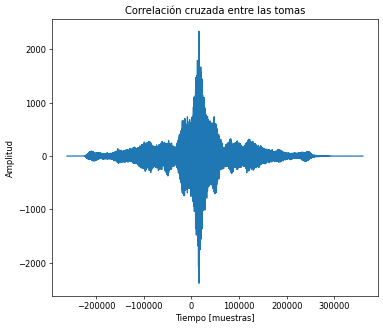

In [71]:
plt.figure(figsize=(7, 6), dpi=60)
plt.plot(lags,corr_s)
plt.ylabel('Amplitud')
plt.xlabel('Tiempo [muestras]')
plt.title('Correlación cruzada entre las tomas')

In [72]:
# Buscamos la máxima correlación, en ese punto las señales quedarán alineadas.

print(np.argmax(corr_s))
print(lags[:10])
print(lags[276906])
lag = lags[np.argmax(corr_s)]
print('La toma de lejos está retrasada '+ str(lag) +' muestras con respecto a la toma directa')

276906
[-260999 -260998 -260997 -260996 -260995 -260994 -260993 -260992 -260991
 -260990]
15907
La toma de lejos está retrasada 15907 muestras con respecto a la toma directa


In [73]:
#Alineamos las señales 
s_lejos_alineada = s_lejos[lag:]

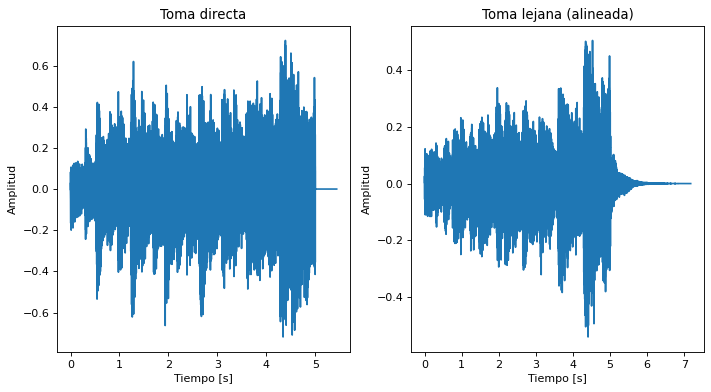

In [74]:
#Verificamos que las señales esten alineadas
t2 = np.linspace(0,len(s_lejos_alineada)/sr,num = len(s_lejos_alineada))
plt.figure(figsize=(9, 5), dpi=80)
plt.subplot(1,2,1)
plt.plot(t1,s_cerca)
plt.ylabel('Amplitud')
plt.xlabel('Tiempo [s]')
plt.title('Toma directa')
plt.subplot(1,2,2)
plt.plot(t2,s_lejos_alineada)
plt.ylabel('Amplitud')
plt.xlabel('Tiempo [s]')
plt.title('Toma lejana (alineada)')
plt.tight_layout()

# EXTRA: Diferencias entre calculos de correlacion (Scipy y Numpy )

In [75]:
t1= time.time()
corr_scipy = sig.correlate(s_lejos,s_cerca)
t2 = time.time()-t1
t3 = time.time()
corr_numpy = np.correlate(s_lejos,s_cerca,'full')
t4 = time.time()-t3


print('El tiempo de ejecución de la versión de Scipy fue: ' + str(round(t2,2))+ ' s')
print('El tiempo de ejecución de la versión de Numpy fue: ' + str(round(t4,2))+ ' s')

El tiempo de ejecución de la versión de Scipy fue: 0.03 s
El tiempo de ejecución de la versión de Numpy fue: 5.17 s


Text(0.5, 1.0, 'Diferencias entre cálculos de correlación')

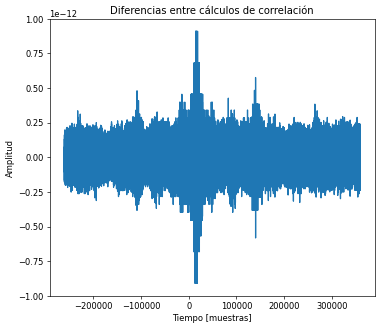

In [76]:

plt.figure(figsize=(7, 6), dpi=60)
plt.plot(lags,corr_scipy-corr_numpy) #notar que si fueran *exactamente* iguales, la diferencia sería 0 en todos los puntos 
plt.ylabel('Amplitud')
plt.xlabel('Tiempo [muestras]')
plt.title('Diferencias entre cálculos de correlación')


El orden de magnitud del eje Y es (10^-12), una diferencia infinitesimal. Se debe a como numpy y scipy manejan los datos:
* Error de punto flotante: SciPy usa la Transformada de Fourier (Convolucion en frecuencia: multiplicacion)
* NumPy usa sumas y multiplicaciones directas (Convolucion en tiempo: multiplicacion y suma).

Matemáticamente son equivalentes. La diferencia que se ve es solo "ruido de redondeo" de la computadora. Para cualquier fin práctico, los resultados son idénticos.